# 02 — Analisis Statistika Deskriptif
Mengikuti alur : **A. Pengorganisasian Data → B. Penyajian Data → C. Statistika Deskriptif**.

Input: `data_analisis.csv` dan `harian_pulau.csv` (hasil notebook 01).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.3f}".format)
data = pd.read_csv("data_analisis.csv", parse_dates=["acq_date"])
harian = pd.read_csv("harian_pulau.csv", parse_dates=["tanggal"])
URUTAN_PULAU = ["Sumatera", "Jawa", "Kalimantan", "Sulawesi", "Bali-Nusa Tenggara", "Maluku", "Papua"]
print(data.shape, harian.shape)

(515450, 13) (12782, 7)


In [2]:
# CEK KELENGKAPAN DATA
print("data_analisis :", data.shape, "| harus (515450, 13)")
print("harian_pulau  :", harian.shape, "| harus (12782, 7)")
print(data["kelompok_tahun"].value_counts())
assert len(data) == 515450, "data_analisis.csv TIDAK LENGKAP - upload ulang dan tunggu sampai lingkaran upload hilang"
assert len(harian) == 12782, "harian_pulau.csv TIDAK LENGKAP - upload ulang"
print("Data lengkap, lanjutkan.")

data_analisis : (515450, 13) | harus (515450, 13)
harian_pulau  : (12782, 7) | harus (12782, 7)
kelompok_tahun
Non-El Nino     279327
El Nino 2023    236123
Name: count, dtype: int64
Data lengkap, lanjutkan.


## A. Pengorganisasian Data — tabel frekuensi

In [3]:
# Frekuensi titik panas per pulau
frek_pulau = data["pulau"].value_counts().reindex(URUTAN_PULAU).to_frame("frekuensi")
frek_pulau["persen"] = frek_pulau["frekuensi"] / frek_pulau["frekuensi"].sum() * 100
frek_pulau

,frekuensi,persen
pulau,,
Sumatera,115474,22.403
Jawa,33002,6.403
Kalimantan,182366,35.380
Sulawesi,38436,7.457
Bali-Nusa Tenggara,95448,18.518
Maluku,13644,2.647
Papua,37073,7.192


In [4]:
# Tabel silang pulau x tahun
tab_pulau_tahun = pd.crosstab(data["pulau"], data["tahun"], margins=True, margins_name="Total")
tab_pulau_tahun = tab_pulau_tahun.reindex(URUTAN_PULAU + ["Total"])
tab_pulau_tahun

tahun,2021,2022,2023,2024,2025,Total
pulau,,,,,,
Sumatera,12672,12485,50835,18607,20875,115474
Jawa,4447,2701,13958,8563,3333,33002
Kalimantan,16772,13901,88165,31193,32335,182366
Sulawesi,4070,3949,17702,6180,6535,38436
Bali-Nusa Tenggara,16402,10153,33995,18513,16385,95448
Maluku,1611,1219,6433,2328,2053,13644
Papua,2809,2923,25032,4556,1753,37073
Total,58783,47331,236120,89940,83269,515443


In [5]:
# Rata-rata titik panas PER TAHUN: El Nino (1 tahun) vs Non-El Nino (4 tahun) -> perbandingan adil
tahunan = pd.crosstab(data["pulau"], data["tahun"]).reindex(URUTAN_PULAU)
banding = pd.DataFrame({
    "El Nino 2023": tahunan[2023],
    "Rata-rata Non-El Nino per tahun": tahunan[[2021, 2022, 2024, 2025]].mean(axis=1),
})
banding["Rasio (kali lipat)"] = banding["El Nino 2023"] / banding["Rata-rata Non-El Nino per tahun"]
banding

,El Nino 2023,Rata-rata Non-El Nino per tahun,Rasio (kali lipat)
pulau,,,
Sumatera,50835,"16,159.750",3.146
Jawa,13958,"4,761.000",2.932
Kalimantan,88165,"23,550.250",3.744
Sulawesi,17702,"5,183.500",3.415
Bali-Nusa Tenggara,33995,"15,363.250",2.213
Maluku,6433,"1,802.750",3.568
Papua,25032,"3,010.250",8.316


In [6]:
# Frekuensi tingkat kepercayaan deteksi (data ordinal)
pd.crosstab(data["confidence"], data["kelompok_tahun"], margins=True).reindex(["l", "n", "h", "All"])

kelompok_tahun,El Nino 2023,Non-El Nino,All
confidence,,,
l,18540,16760,35300
n,209484,255138,464622
h,8099,7429,15528
All,236123,279327,515450


## B. Penyajian Data — grafik

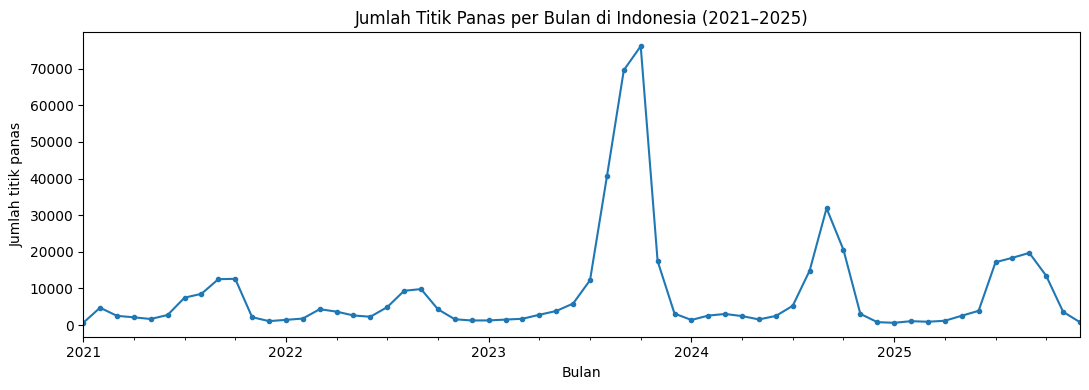

In [7]:
# Grafik garis: jumlah titik panas per bulan 2021-2025
bulanan = data.groupby(data["acq_date"].dt.to_period("M")).size()
ax = bulanan.plot(kind="line", figsize=(11, 4), marker="o", markersize=3)
ax.set_title("Jumlah Titik Panas per Bulan di Indonesia (2021–2025)")
ax.set_xlabel("Bulan"); ax.set_ylabel("Jumlah titik panas")
plt.tight_layout(); plt.savefig("grafik_garis_bulanan.png", dpi=150); plt.show()

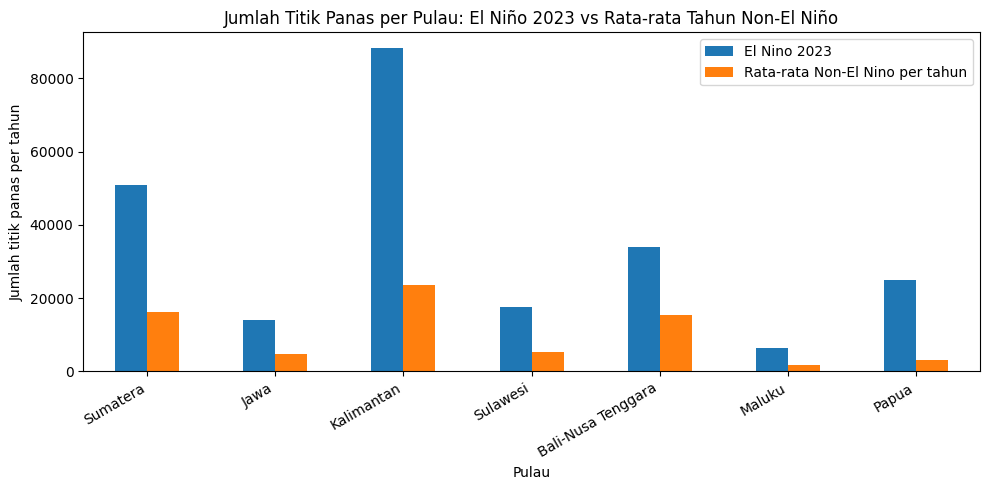

In [8]:
# Grafik batang: El Nino 2023 vs rata-rata tahun Non-El Nino per pulau
ax = banding[["El Nino 2023", "Rata-rata Non-El Nino per tahun"]].plot(kind="bar", figsize=(10, 5))
ax.set_title("Jumlah Titik Panas per Pulau: El Niño 2023 vs Rata-rata Tahun Non-El Niño")
ax.set_xlabel("Pulau"); ax.set_ylabel("Jumlah titik panas per tahun")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig("grafik_batang_pulau.png", dpi=150); plt.show()

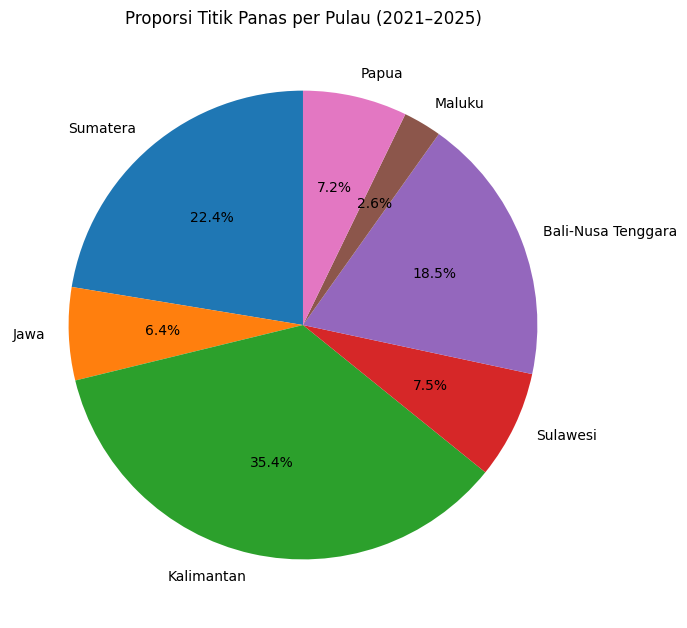

In [9]:
# Pie chart: proporsi titik panas per pulau (2021-2025)
ax = frek_pulau["frekuensi"].plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7), startangle=90)
ax.set_title("Proporsi Titik Panas per Pulau (2021–2025)"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig("grafik_pie_pulau.png", dpi=150); plt.show()

## C. Statistika Deskriptif
Semua ukuran pada modul: mean, median, modus, min, max, kuartil, IQR, varians, SD, SE, skewness, kurtosis (excess), ditambah koefisien variasi (CV) karena skala data bukan 0–100.

In [10]:
def statistik_deskriptif(x):
    x = x.dropna()
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({
        "n": x.count(), "mean": x.mean(), "median": x.median(), "modus": x.mode().iloc[0],
        "min": x.min(), "Q1": q1, "Q3": q3, "max": x.max(), "IQR": iqr,
        "varians": x.var(), "std": x.std(), "SE": x.sem(),
        "CV (%)": x.std() / x.mean() * 100,
        "skewness": x.skew(), "kurtosis": x.kurt(),
        "outlier (IQR)": ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum(),
    })

In [11]:
# Variabel utama 1: jumlah titik panas harian per pulau
desk_harian_kelompok = harian.groupby("kelompok_tahun")["jumlah_titik_panas"].apply(statistik_deskriptif).unstack()
desk_harian_kelompok

,n,mean,median,modus,min,Q1,Q3,max,IQR,varians,std,SE,CV (%),skewness,kurtosis,outlier (IQR)
kelompok_tahun,,,,,,,,,,,,,,,,
El Nino 2023,"2,541.000",92.924,16.000,0.000,0.000,3.000,66.000,"2,869.000",63.000,"57,256.140",239.283,4.747,257.503,5.355,36.641,330.000
Non-El Nino,"9,975.000",28.002,5.000,0.000,0.000,1.000,20.000,"2,848.000",19.000,"7,985.543",89.362,0.895,319.123,13.358,291.168,"1,306.000"


In [12]:
desk_harian_pulau = (harian.groupby("pulau")["jumlah_titik_panas"].apply(statistik_deskriptif)
                     .unstack().reindex(URUTAN_PULAU))
desk_harian_pulau

,n,mean,median,modus,min,Q1,Q3,max,IQR,varians,std,SE,CV (%),skewness,kurtosis,outlier (IQR)
pulau,,,,,,,,,,,,,,,,
Sumatera,"1,788.000",64.583,21.000,0.000,0.000,6.000,61.250,"2,090.000",55.250,"23,179.406",152.248,3.601,235.741,6.860,64.061,177.000
Jawa,"1,788.000",18.457,4.000,0.000,0.000,1.000,17.000,264.000,16.000,"1,264.096",35.554,0.841,192.627,3.330,13.026,236.000
Kalimantan,"1,788.000",101.994,16.000,0.000,0.000,5.000,53.000,"2,869.000",48.000,"81,206.998",284.968,6.739,279.396,5.184,32.582,256.000
Sulawesi,"1,788.000",21.497,8.000,0.000,0.000,3.000,21.000,490.000,18.000,"1,828.715",42.763,1.011,198.931,4.741,29.886,184.000
Bali-Nusa Tenggara,"1,788.000",53.383,6.000,0.000,0.000,0.000,62.000,768.000,62.000,"9,425.283",97.084,2.296,181.864,2.759,9.265,205.000
Maluku,"1,788.000",7.631,2.000,0.000,0.000,0.000,7.000,239.000,7.000,278.201,16.679,0.394,218.577,5.371,42.420,199.000
Papua,"1,788.000",20.734,3.000,0.000,0.000,0.000,11.000,"1,404.000",11.000,"6,700.871",81.859,1.936,394.798,9.168,109.085,207.000


In [13]:
# Variabel utama 2: FRP (MW) per titik panas
desk_frp_kelompok = data.groupby("kelompok_tahun")["frp"].apply(statistik_deskriptif).unstack()
desk_frp_kelompok

,n,mean,median,modus,min,Q1,Q3,max,IQR,varians,std,SE,CV (%),skewness,kurtosis,outlier (IQR)
kelompok_tahun,,,,,,,,,,,,,,,,
El Nino 2023,"236,123.000",7.812,4.930,3.530,0.000,2.750,8.570,943.380,5.820,143.988,12.000,0.025,153.604,11.689,373.777,"19,917.000"
Non-El Nino,"279,327.000",7.731,4.810,3.430,0.000,2.890,8.270,657.140,5.380,131.762,11.479,0.022,148.480,8.775,177.074,"25,002.000"


In [14]:
desk_frp_pulau = data.groupby("pulau")["frp"].apply(statistik_deskriptif).unstack().reindex(URUTAN_PULAU)
desk_frp_pulau

,n,mean,median,modus,min,Q1,Q3,max,IQR,varians,std,SE,CV (%),skewness,kurtosis,outlier (IQR)
pulau,,,,,,,,,,,,,,,,
Sumatera,"115,474.000",7.255,4.450,0.980,0.000,2.370,7.990,722.700,5.620,136.685,11.691,0.034,161.157,12.528,396.599,"9,466.000"
Jawa,"33,002.000",4.202,2.960,0.680,0.100,1.530,4.890,242.240,3.360,37.144,6.095,0.034,145.034,10.566,206.677,"2,037.000"
Kalimantan,"182,366.000",9.570,5.750,3.040,0.000,3.290,10.400,943.380,7.110,201.254,14.186,0.033,148.232,8.996,217.380,"16,927.000"
Sulawesi,"38,436.000",6.770,4.430,2.800,0.100,2.790,7.190,317.080,4.400,97.849,9.892,0.050,146.114,9.580,169.966,"3,323.000"
Bali-Nusa Tenggara,"95,448.000",6.926,4.790,3.410,0.090,3.087,7.640,280.150,4.553,85.138,9.227,0.030,133.220,8.692,131.275,"7,385.000"
Maluku,"13,644.000",5.862,4.220,2.820,0.170,2.450,6.842,154.700,4.392,48.449,6.961,0.060,118.748,6.707,83.303,970.000
Papua,"37,073.000",7.579,5.200,4.160,0.130,3.390,8.310,335.060,4.920,90.247,9.500,0.049,125.340,7.543,111.473,"3,045.000"


FRP = 0 dikecualikan : 12 titik
Skewness FRP         : 10.214  -> log(FRP): 0.029
Kurtosis FRP         : 276.458  -> log(FRP): 0.65


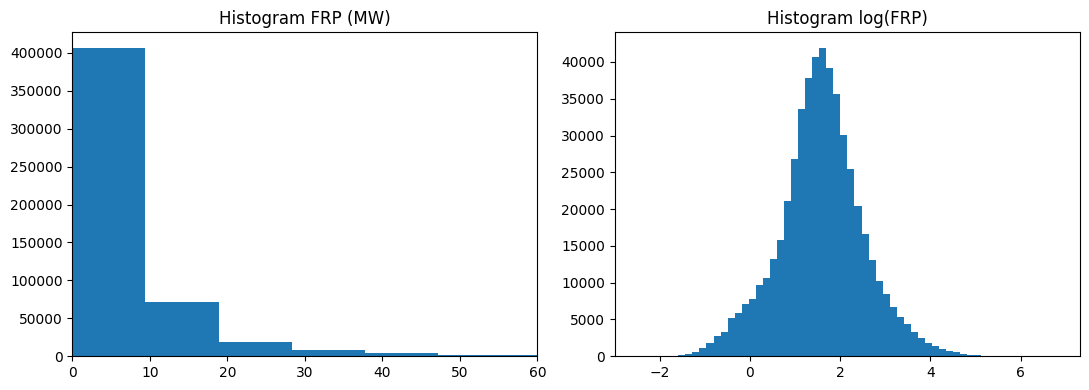

In [15]:
# FRP sangat menceng kanan -> cek bentuk setelah transformasi log (FRP = 0 dikecualikan karena log(0) tak terdefinisi)
frp_positif = data.loc[data["frp"] > 0, "frp"]
print("FRP = 0 dikecualikan :", (data["frp"] == 0).sum(), "titik")
print("Skewness FRP         :", round(data["frp"].skew(), 3), " -> log(FRP):", round(np.log(frp_positif).skew(), 3))
print("Kurtosis FRP         :", round(data["frp"].kurt(), 3), " -> log(FRP):", round(np.log(frp_positif).kurt(), 3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(data["frp"], bins=100); ax[0].set_title("Histogram FRP (MW)"); ax[0].set_xlim(0, 60)
ax[1].hist(np.log(frp_positif), bins=60); ax[1].set_title("Histogram log(FRP)")
plt.tight_layout(); plt.savefig("histogram_frp.png", dpi=150); plt.show()

In [16]:
# Simpan semua tabel ke file Excel
with pd.ExcelWriter("hasil_analisis_deskriptif.xlsx") as w:
    frek_pulau.to_excel(w, sheet_name="frek_pulau")
    tab_pulau_tahun.to_excel(w, sheet_name="pulau_x_tahun")
    banding.to_excel(w, sheet_name="elnino_vs_non")
    desk_harian_kelompok.to_excel(w, sheet_name="desk_harian_kelompok")
    desk_harian_pulau.to_excel(w, sheet_name="desk_harian_pulau")
    desk_frp_kelompok.to_excel(w, sheet_name="desk_frp_kelompok")
    desk_frp_pulau.to_excel(w, sheet_name="desk_frp_pulau")
print("Tersimpan: hasil_analisis_deskriptif.xlsx")

Tersimpan: hasil_analisis_deskriptif.xlsx
